In [58]:
from data_processing import DataSetup, FigureFormat

flight_matrix_path = '/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/country_flow_202001 1.csv'
country_codes_path = '/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/geom_countries_codes.csv'
population_path = '/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/WPP2019_TotalPopulation2020.csv'

flight_matrix, normalized_flow_matrix, source_countries, target_countries, source_codes, target_codes, population, name_mapping = DataSetup(flight_matrix_path, population_path, country_codes_path).load_and_process_data().values()
FigureFormat().set_figure_format()

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.interpolate import Rbf
import ast
import re
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Helper function to parse arrays safely
def safe_parse_array(x):
    if pd.isna(x) or x is None:
        return np.array([])
    if isinstance(x, str):
        if x.strip() == 'Float64[]' or x.strip() == '[]':
            return np.array([])
        x = re.sub(r'Float64\[', '[', x)
        try:
            return np.array(ast.literal_eval(x))
        except:
            return np.array([])
    return x

Figure 3A

Countries after aggregation: 222
Homoskedasticity check: slope = -0.1733, p = 0.0000
Final number of countries: 220


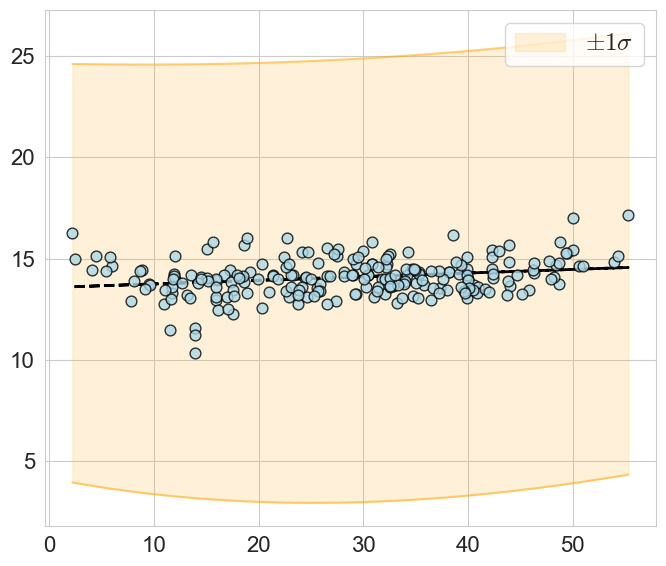

Correlation between Arrival Time and Lead Time: 0.237
P-value: 3.8380e-04


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.interpolate import UnivariateSpline

# Load datasets
ww_detection_data = pd.read_csv('/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/full_results.csv')
daily_arrival = pd.read_csv('/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/simulated_arrival_vs_detection_times.csv')

# Calculate Arrival Times
arrival_times_list = []
for country in daily_arrival['country'].unique():
    country_data = daily_arrival[daily_arrival['country'] == country]
    mean_arrival_time = country_data['mean_arrival_time'].values[0]
    arrival_times_list.append({'country': country, 'arrival_time': mean_arrival_time})
    
arrival_df = pd.DataFrame(arrival_times_list)

# Calculate mean lead time (ICU - WW) and std across parameter combinations
ww_detection_data['lead_time'] = ww_detection_data['ICU_mean_detection_time'] - ww_detection_data['WW_016_10pct_mean_detection_time']

# Aggregate by country: mean lead time and std of lead time across R0/gen_time combinations
country_aggregated = ww_detection_data.groupby('country').agg({
    'lead_time': ['mean', 'std']
}).reset_index()

# Flatten column names
country_aggregated.columns = ['country', 'mean_lead', 'std_lead']

print(f"Countries after aggregation: {len(country_aggregated)}")

# Check homoskedasticity
valid_diffs = country_aggregated.dropna(subset=['mean_lead', 'std_lead'])
slope, intercept, r_val, p_val, _ = stats.linregress(valid_diffs['mean_lead'], valid_diffs['std_lead'])
print(f"Homoskedasticity check: slope = {slope:.4f}, p = {p_val:.4f}")

# --- 3. MERGE AND PREPARE PLOT ---

# Combine arrival timing with lead-time statistics
final_df = country_aggregated.merge(arrival_df, on='country').dropna(subset=['arrival_time', 'mean_lead'])

# Remove problematic countries
final_df = final_df[~final_df['country'].isin(['North Korea', 'Yemen', 'United Kingdom', 'Unknown Country'])]

print(f"Final number of countries: {len(final_df)}")

x = final_df['arrival_time'].values
y = final_df['mean_lead'].values
stds = final_df['std_lead'].values

# Sort by Arrival Time
sort_idx = np.argsort(x)
x_sorted, y_sorted, std_sorted = x[sort_idx], y[sort_idx], stds[sort_idx]

# --- 4. SMOOTH INTERPOLATION ---

# Create smooth spline fits for mean and boundaries
# Use smoothing parameter s - larger values = smoother curves
smoothing_factor = len(x_sorted) * 2.0  # Adjust this to control smoothness

# Fit splines
spline_mean = UnivariateSpline(x_sorted, y_sorted, s=smoothing_factor, k=3)
spline_upper = UnivariateSpline(x_sorted, y_sorted + std_sorted, s=smoothing_factor, k=3)
spline_lower = UnivariateSpline(x_sorted, y_sorted - std_sorted, s=smoothing_factor, k=3)

# Generate smooth curves
x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), 300)
y_smooth = spline_mean(x_smooth)
upper_smooth = spline_upper(x_smooth)
lower_smooth = spline_lower(x_smooth)

# --- 5. PLOTTING ---

fig, ax = plt.subplots(figsize=(7, 6))
sns.set_style("whitegrid")

# Smooth Bounds
ax.fill_between(x_smooth, lower_smooth, upper_smooth, color='orange', alpha=0.15, 
                label='$\pm 1\sigma$', zorder=1)
ax.plot(x_smooth, upper_smooth, color='orange', lw=1.5, alpha=0.5, zorder=2)
ax.plot(x_smooth, lower_smooth, color='orange', lw=1.5, alpha=0.5, zorder=2)

# Global Trend
slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
ax.plot(x, slope*x + intercept, 'k--', lw=2, zorder=4)#, label=f'Trend (r={r_val:.3f})')

# Data Points
ax.scatter(x, y, c='lightblue', s=60, edgecolors='black', alpha=0.8, zorder=5)

# ax.set_xlabel('Arrival Time (Days)', fontsize=14)
# ax.set_ylabel('Mean Detection Time Difference (ICU - WW) (Days)', fontsize=14)
ax.tick_params(labelsize=16)
ax.legend(loc='upper right', frameon=True, fontsize=18)

plt.tight_layout()
plt.savefig('/Users/reddy/figures/lead_time_vs_arrival_smooth.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Correlation between Arrival Time and Lead Time: {r_val:.3f}")
print(f"P-value: {p_val:.4e}")

Just WW

Figure 3C

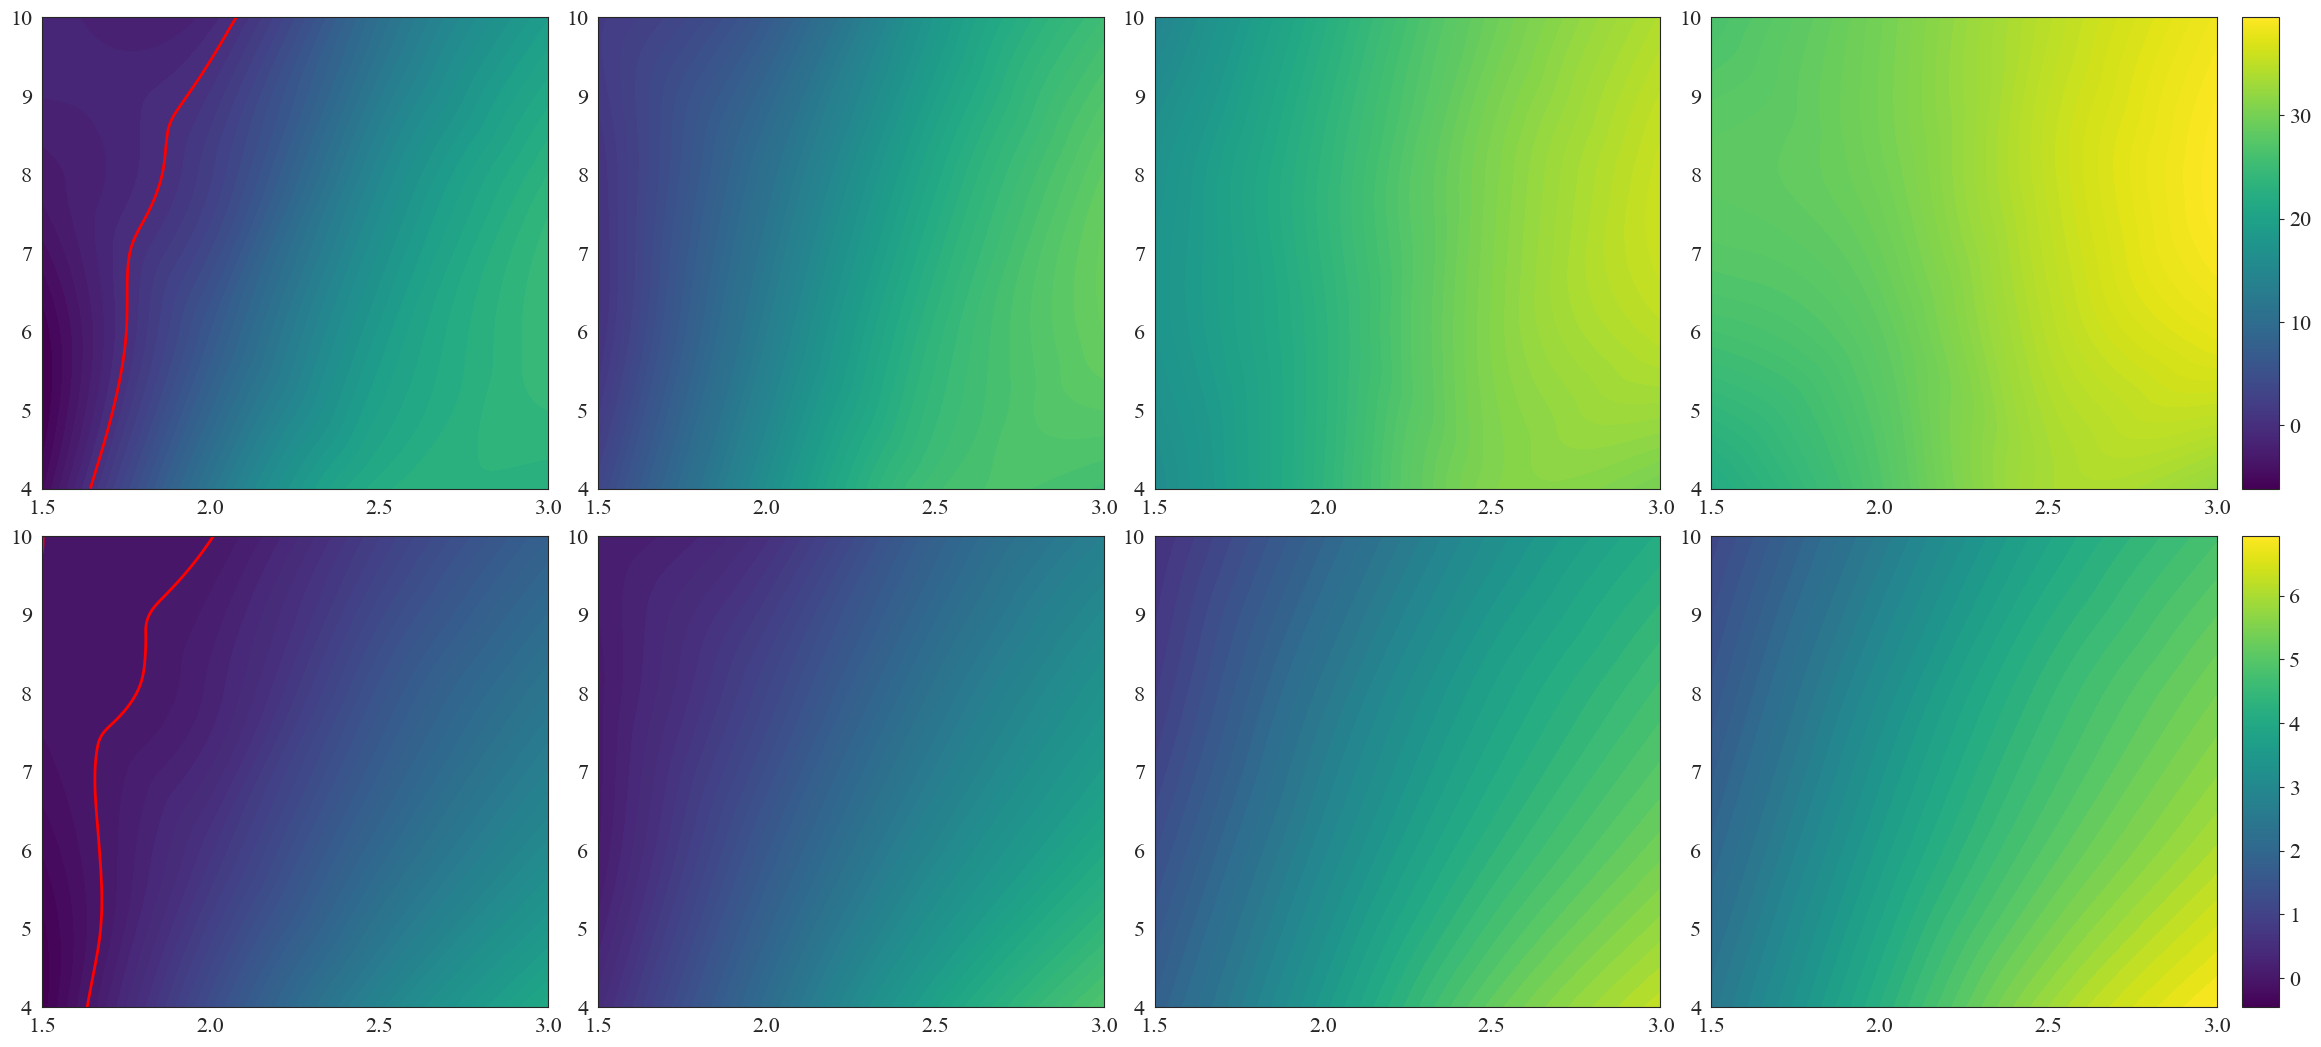

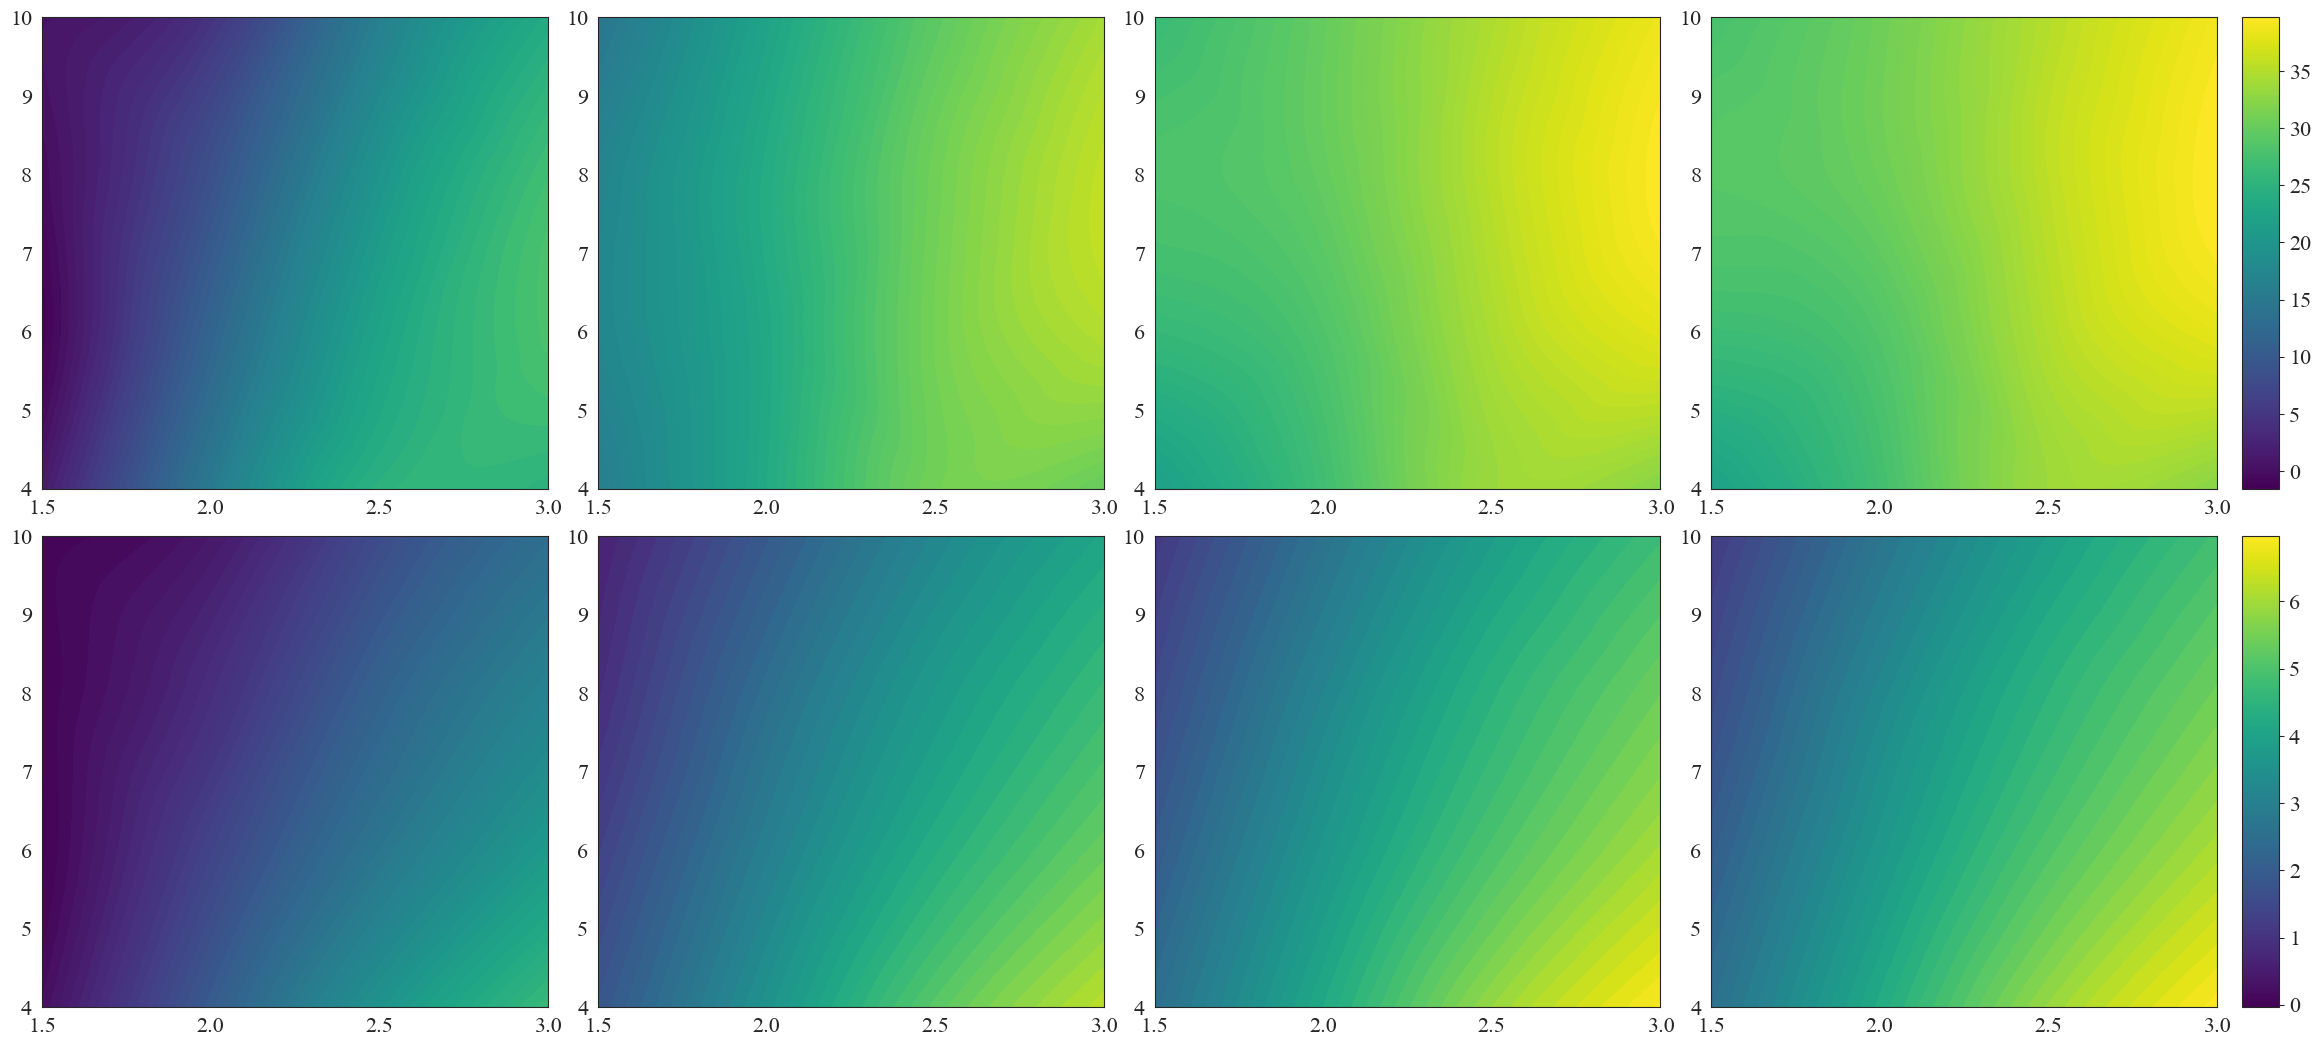

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import Rbf, griddata
from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams.update({'font.size': 18})

# Load data
df = pd.read_csv("/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/comparison_simple_vs_hierarchical_CIs.csv")
df_filtered = df.copy()

# Prepare data
R0_data = df_filtered['R0'].values
gen_time_data = df_filtered['gen_time'].values

# Create grid
R0_grid = np.linspace(1.5, 3.0, 200)
gen_time_grid = np.linspace(4.0, 10.0, 200)
R0_mesh, gen_time_mesh = np.meshgrid(R0_grid, gen_time_grid)

cmap = 'viridis'

# ============================================================================
# FIGURE 1: BASE P_DET = 8% - ICU vs AWW COMPARISON (ICU - AWW)
# ============================================================================
fig1 = plt.figure(figsize=(25, 11))
gs1 = fig1.add_gridspec(2, 4, hspace=0.1, wspace=0.1, left=0.05, right=0.92, top=0.95, bottom=0.05)
axes1 = gs1.subplots()

# 4 sampling fractions for base=8%
configs_008 = [
    ('008_10pct', '10% sampling (eff=0.8%)'),
    ('008_25pct', '25% sampling (eff=2.0%)'),
    ('008_50pct', '50% sampling (eff=4.0%)'),
    ('008_100pct', '100% sampling (eff=8.0%)')
]

# Calculate ICU - AWW for detection times
time_diffs_008 = []
for cfg, _ in configs_008:
    col_name = f'WW_{cfg}_time_simple_mean'
    diff = df_filtered['ICU_time_simple_mean'] - df_filtered[col_name]
    time_diffs_008.append(diff.values)

# Calculate ICU - AWW for local cases
cases_diffs_008 = []
for cfg, _ in configs_008:
    col_name = f'WW_{cfg}_cases_simple_mean'
    diff = np.log(df_filtered['ICU_cases_simple_mean'] / df_filtered[col_name])
    cases_diffs_008.append(diff.values)

# Global vmin/vmax for TIME differences
all_time_diffs = np.concatenate(time_diffs_008)
time_vmin_008 = np.nanmin(all_time_diffs)
time_vmax_008 = np.nanmax(all_time_diffs)

# Global vmin/vmax for CASES differences
all_cases_diffs = np.concatenate(cases_diffs_008)
cases_vmin_008 = np.nanmin(all_cases_diffs)
cases_vmax_008 = np.nanmax(all_cases_diffs)

# TOP ROW: ICU - AWW Detection Time Difference
for idx, (config_name, label) in enumerate(configs_008):
    ax = axes1[0, idx]
    values = time_diffs_008[idx]
    
    points = np.column_stack([R0_data, gen_time_data])
    grid_z = griddata(points, values, (R0_mesh, gen_time_mesh), method='cubic')
    
    norm = Normalize(vmin=time_vmin_008, vmax=time_vmax_008)
    contour = ax.contourf(R0_mesh, gen_time_mesh, grid_z, levels=50, cmap=cmap, norm=norm)
    
    # Add contour line at 0
    contour_line = ax.contour(R0_mesh, gen_time_mesh, grid_z, levels=[0], colors='red', linewidths=2)
    
    ax.set_xlim(1.5, 3.0)
    ax.set_ylim(4.0, 10.0)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_yticks([4, 5, 6, 7, 8, 9, 10])
    ax.set_xticks([1.5, 2.0, 2.5, 3.0])

# Get position of top row to match colorbar height
top_row_bbox = axes1[0, -1].get_position()
cbar_ax_top = fig1.add_axes([0.93, top_row_bbox.y0, 0.015, top_row_bbox.height])
sm_time_008 = ScalarMappable(norm=Normalize(vmin=time_vmin_008, vmax=time_vmax_008), cmap=cmap)
sm_time_008.set_array([])
cbar_top_008 = fig1.colorbar(sm_time_008, cax=cbar_ax_top)
cbar_top_008.ax.tick_params(labelsize=16)

# BOTTOM ROW: ICU - AWW Cases Difference (log ratio)
for idx, (config_name, label) in enumerate(configs_008):
    ax = axes1[1, idx]
    values = cases_diffs_008[idx]
    
    # Griddata interpolation
    points = np.column_stack([R0_data, gen_time_data])
    grid_z = griddata(points, values, (R0_mesh, gen_time_mesh), method='cubic')
    grid_z = np.clip(grid_z, cases_vmin_008, cases_vmax_008)
    
    norm = Normalize(vmin=cases_vmin_008, vmax=cases_vmax_008)
    contour = ax.contourf(R0_mesh, gen_time_mesh, grid_z, levels=50, cmap=cmap, norm=norm)
    
    # Add contour line at 0 (which equals ratio of 1)
    contour_line = ax.contour(R0_mesh, gen_time_mesh, grid_z, levels=[0], colors='red', linewidths=2)
    
    ax.set_xlim(1.5, 3.0)
    ax.set_ylim(4.0, 10.0)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_yticks([4, 5, 6, 7, 8, 9, 10])
    ax.set_xticks([1.5, 2.0, 2.5, 3.0])

# Get position of bottom row to match colorbar height
bottom_row_bbox = axes1[1, -1].get_position()
cbar_ax_bottom = fig1.add_axes([0.93, bottom_row_bbox.y0, 0.015, bottom_row_bbox.height])
sm_cases_008 = ScalarMappable(norm=Normalize(vmin=cases_vmin_008, vmax=cases_vmax_008), cmap=cmap)
sm_cases_008.set_array([])
cbar_bottom_008 = fig1.colorbar(sm_cases_008, cax=cbar_ax_bottom)
cbar_bottom_008.ax.tick_params(labelsize=16)

plt.savefig("/Users/reddy/figures/heatmap_base_008_ICU_vs_AWW.pdf", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 2: BASE P_DET = 16% - ICU vs AWW COMPARISON (ICU - AWW)
# ============================================================================
fig2 = plt.figure(figsize=(25, 11))
gs2 = fig2.add_gridspec(2, 4, hspace=0.1, wspace=0.1, left=0.05, right=0.92, top=0.95, bottom=0.05)
axes2 = gs2.subplots()

# 4 sampling fractions for base=16%
configs_016 = [
    ('016_10pct', '10% sampling (eff=1.6%)'),
    ('016_25pct', '25% sampling (eff=4.0%)'),
    ('016_50pct', '50% sampling (eff=8.0%)'),
    ('016_100pct', '100% sampling (eff=16.0%)')
]

# Calculate ICU - AWW for detection times
time_diffs_016 = []
for cfg, _ in configs_016:
    col_name = f'WW_{cfg}_time_simple_mean'
    diff = df_filtered['ICU_time_simple_mean'] - df_filtered[col_name]
    time_diffs_016.append(diff.values)

# Calculate ICU - AWW for local cases
cases_diffs_016 = []
for cfg, _ in configs_016:
    col_name = f'WW_{cfg}_cases_simple_mean'
    diff = np.log(df_filtered['ICU_cases_simple_mean'] / df_filtered[col_name])
    cases_diffs_016.append(diff.values)

# Global vmin/vmax for TIME differences
all_time_diffs_016 = np.concatenate(time_diffs_016)
time_vmin_016 = np.nanmin(all_time_diffs_016)
time_vmax_016 = np.nanmax(all_time_diffs_016)

# Global vmin/vmax for CASES differences
all_cases_diffs_016 = np.concatenate(cases_diffs_016)
cases_vmin_016 = np.nanmin(all_cases_diffs_016)
cases_vmax_016 = np.nanmax(all_cases_diffs_016)

# TOP ROW: ICU - AWW Detection Time Difference
for idx, (config_name, label) in enumerate(configs_016):
    ax = axes2[0, idx]
    values = time_diffs_016[idx]
    
    points = np.column_stack([R0_data, gen_time_data])
    grid_z = griddata(points, values, (R0_mesh, gen_time_mesh), method='cubic')
    
    norm = Normalize(vmin=time_vmin_016, vmax=time_vmax_016)
    contour = ax.contourf(R0_mesh, gen_time_mesh, grid_z, levels=50, cmap=cmap, norm=norm)
    
    # Add contour line at 0
    # contour_line = ax.contour(R0_mesh, gen_time_mesh, grid_z, levels=[0], colors='red', linewidths=2)
    
    ax.set_xlim(1.5, 3.0)
    ax.set_ylim(4.0, 10.0)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_yticks([4, 5, 6, 7, 8, 9, 10])
    ax.set_xticks([1.5, 2.0, 2.5, 3.0])

# Get position of top row to match colorbar height
top_row_bbox = axes2[0, -1].get_position()
cbar_ax_top_016 = fig2.add_axes([0.93, top_row_bbox.y0, 0.015, top_row_bbox.height])
sm_time_016 = ScalarMappable(norm=Normalize(vmin=time_vmin_016, vmax=time_vmax_016), cmap=cmap)
sm_time_016.set_array([])
cbar_top_016 = fig2.colorbar(sm_time_016, cax=cbar_ax_top_016)
cbar_top_016.ax.tick_params(labelsize=16)

# BOTTOM ROW: ICU - AWW Cases Difference (log ratio)
for idx, (config_name, label) in enumerate(configs_016):
    ax = axes2[1, idx]
    values = cases_diffs_016[idx]
    
    points = np.column_stack([R0_data, gen_time_data])
    grid_z = griddata(points, values, (R0_mesh, gen_time_mesh), method='cubic')
    grid_z = np.clip(grid_z, cases_vmin_016, cases_vmax_016)
    
    norm = Normalize(vmin=cases_vmin_016, vmax=cases_vmax_016)
    contour = ax.contourf(R0_mesh, gen_time_mesh, grid_z, levels=50, cmap=cmap, norm=norm)
    
    # Add contour line at 0 (which equals ratio of 1)
    # contour_line = ax.contour(R0_mesh, gen_time_mesh, grid_z, levels=[0], colors='red', linewidths=2)
    
    ax.set_xlim(1.5, 3.0)
    ax.set_ylim(4.0, 10.0)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_yticks([4, 5, 6, 7, 8, 9, 10])
    ax.set_xticks([1.5, 2.0, 2.5, 3.0])

# Get position of bottom row to match colorbar height
bottom_row_bbox = axes2[1, -1].get_position()
cbar_ax_bottom_016 = fig2.add_axes([0.93, bottom_row_bbox.y0, 0.015, bottom_row_bbox.height])
sm_cases_016 = ScalarMappable(norm=Normalize(vmin=cases_vmin_016, vmax=cases_vmax_016), cmap=cmap)
sm_cases_016.set_array([])
cbar_bottom_016 = fig2.colorbar(sm_cases_016, cax=cbar_ax_bottom_016)
cbar_bottom_016.ax.tick_params(labelsize=16)

plt.savefig("/Users/reddy/figures/heatmap_base_016_ICU_vs_AWW.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [126]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("/Users/reddy/AWW_and_ICU/pgfgleam/pgfgleam/datasets/comparison_simple_vs_hierarchical_CIs.csv")
df_filtered = df.copy()

# Print ranges for each configuration
print("="*80)
print("HEATMAP VALUE RANGES (TRUE DATA, NOT INTERPOLATED)")
print("="*80)

# BASE P_DET = 8% RANGES
print("\n" + "="*80)
print("FIGURE 1: BASE P_DET = 8%")
print("="*80)

configs_008 = [
    ('008_10pct', '10% sampling (eff=0.8%)'),
    ('008_25pct', '25% sampling (eff=2.0%)'),
    ('008_50pct', '50% sampling (eff=4.0%)'),
    ('008_100pct', '100% sampling (eff=8.0%)')
]

print("\n--- DETECTION TIME DIFFERENCES (ICU - AWW) ---")
for cfg, label in configs_008:
    col_name = f'WW_{cfg}_time_simple_mean'
    diff = df_filtered['ICU_time_simple_mean'] - df_filtered[col_name]
    print(f"\n{label}:")
    print(f"  Range: [{diff.min():.2f}, {diff.max():.2f}] days")
    print(f"  Mean: {diff.mean():.2f} days")
    print(f"  Median: {diff.median():.2f} days")

print("\n--- LOCAL CASES LOG RATIOS (log(ICU / AWW)) ---")
for cfg, label in configs_008:
    col_name = f'WW_{cfg}_cases_simple_mean'
    log_ratio = np.log(df_filtered['ICU_cases_simple_mean'] / df_filtered[col_name])
    print(f"\n{label}:")
    print(f"  Range: [{log_ratio.min():.3f}, {log_ratio.max():.3f}]")
    print(f"  Mean: {log_ratio.mean():.3f}")
    print(f"  Median: {log_ratio.median():.3f}")
    actual_ratio = df_filtered['ICU_cases_simple_mean'] / df_filtered[col_name]
    print(f"  Actual ratio range: [{actual_ratio.min():.2f}x, {actual_ratio.max():.2f}x]")

# BASE P_DET = 16% RANGES
print("\n" + "="*80)
print("FIGURE 2: BASE P_DET = 16%")
print("="*80)

configs_016 = [
    ('016_10pct', '10% sampling (eff=1.6%)'),
    ('016_25pct', '25% sampling (eff=4.0%)'),
    ('016_50pct', '50% sampling (eff=8.0%)'),
    ('016_100pct', '100% sampling (eff=16.0%)')
]

print("\n--- DETECTION TIME DIFFERENCES (ICU - AWW) ---")
for cfg, label in configs_016:
    col_name = f'WW_{cfg}_time_simple_mean'
    diff = df_filtered['ICU_time_simple_mean'] - df_filtered[col_name]
    print(f"\n{label}:")
    print(f"  Range: [{diff.min():.2f}, {diff.max():.2f}] days")
    print(f"  Mean: {diff.mean():.2f} days")
    print(f"  Median: {diff.median():.2f} days")

print("\n--- LOCAL CASES LOG RATIOS (log(ICU / AWW)) ---")
for cfg, label in configs_016:
    col_name = f'WW_{cfg}_cases_simple_mean'
    log_ratio = df_filtered['ICU_cases_simple_mean'] / df_filtered[col_name]
    print(f"\n{label}:")
    print(f"  Range: [{log_ratio.min():.3f}, {log_ratio.max():.3f}]")
    print(f"  Mean: {log_ratio.mean():.3f}")
    print(f"  Median: {log_ratio.median():.3f}")
    actual_ratio = df_filtered['ICU_cases_simple_mean'] / df_filtered[col_name]
    print(f"  Actual ratio range: [{actual_ratio.min():.2f}x, {actual_ratio.max():.2f}x]")

print("\n" + "="*80)
print("END OF RANGES")
print("="*80)

HEATMAP VALUE RANGES (TRUE DATA, NOT INTERPOLATED)

FIGURE 1: BASE P_DET = 8%

--- DETECTION TIME DIFFERENCES (ICU - AWW) ---

10% sampling (eff=0.8%):
  Range: [-6.17, 24.69] days
  Mean: 9.98 days
  Median: 10.97 days

25% sampling (eff=2.0%):
  Range: [0.52, 28.81] days
  Mean: 15.60 days
  Median: 17.24 days

50% sampling (eff=4.0%):
  Range: [14.48, 35.73] days
  Mean: 25.88 days
  Median: 26.46 days

100% sampling (eff=8.0%):
  Range: [21.77, 39.51] days
  Mean: 31.45 days
  Median: 31.00 days

--- LOCAL CASES LOG RATIOS (log(ICU / AWW)) ---

10% sampling (eff=0.8%):
  Range: [-0.460, 3.963]
  Mean: 1.231
  Median: 1.071
  Actual ratio range: [0.63x, 52.64x]

25% sampling (eff=2.0%):
  Range: [0.064, 4.895]
  Mean: 1.991
  Median: 1.987
  Actual ratio range: [1.07x, 133.59x]

50% sampling (eff=4.0%):
  Range: [0.575, 6.243]
  Mean: 3.265
  Median: 3.356
  Actual ratio range: [1.78x, 514.34x]

100% sampling (eff=8.0%):
  Range: [1.110, 6.937]
  Mean: 3.936
  Median: 4.034
  Actual